# Lab Activity 4 -- Solutions

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

# Read in the datasets
peng = pd.read_csv("../../data/penguins.csv")
bike = pd.read_csv("../../data/bike-sharing-daily.csv", parse_dates=["dteday"])

In [2]:
# Drop penguins missing any of the four numeric variables or sex (same as previously)
peng_clean = peng.dropna(
    subset=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "sex"]
).reset_index(drop=True)
peng_clean.shape  # expect (333, 8)

(333, 8)

## Part 1: From statsmodels to sklearn

In [3]:
# Question #1
# Fit "body_mass_g ~ flipper_length_mm + C(sex) + C(species)" with statsmodels
sm_model = smf.ols("body_mass_g ~ flipper_length_mm + C(sex) + C(species)", data=peng_clean).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     534.0
Date:                Thu, 01 Oct 2026   Prob (F-statistic):          3.37e-142
Time:                        13:30:56   Log-Likelihood:                -2364.4
No. Observations:                 333   AIC:                             4739.
Df Residuals:                     328   BIC:                             4758.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                -

**Q1** 
Coefficients and $R^2$ as above in statsmodels output. 
Reference levels: 
* For sex: female
* For species: Adelie
* Coefficient C(species)[T.Gentoo]: Holding flipper length and sex fixed, Gentoo penguins weigh on average 836g more than Adelie penguins. 

In [4]:
#Q2a - Now fit this model with sklearn. 

# First create X and y
# We have to construct the matrix of dummy variables because sklearn won't do it for us. 
y = peng_clean["body_mass_g"]
X_dummy = pd.get_dummies(peng_clean[["flipper_length_mm", "sex", "species"]], drop_first=True)

# Run model with sklearn and confirm that the results match
lr_dummy = LinearRegression().fit(X_dummy, y)

coef_dummy = pd.Series(
    np.r_[lr_dummy.intercept_, lr_dummy.coef_],
    index=["Intercept"] + list(X_dummy.columns),
)
print("sklearn R^2:", lr_dummy.score(X_dummy, y))
coef_dummy

sklearn R^2: 0.8668883562330879


Intercept           -365.817450
flipper_length_mm     20.024915
sex_male             530.381094
species_Chinstrap    -87.634478
species_Gentoo       836.260008
dtype: float64

In [5]:
# Line up the statsmodels names with the sklearn column names
# Compute the differences between each modeling type. 
# The table below will show that they are the same. 

name_map = {
    "Intercept": "Intercept",
    "flipper_length_mm": "flipper_length_mm",
    "C(sex)[T.male]": "sex_male",
    "C(species)[T.Chinstrap]": "species_Chinstrap",
    "C(species)[T.Gentoo]": "species_Gentoo",
}
comparison = pd.DataFrame({
    "statsmodels": sm_model.params.rename(name_map),
    "sklearn": coef_dummy,
})
comparison["difference"] = comparison["statsmodels"] - comparison["sklearn"]
print("statsmodels R^2:", sm_model.rsquared, "| sklearn R^2:", lr_dummy.score(X_dummy, y))
comparison

statsmodels R^2: 0.8668883562330879 | sklearn R^2: 0.8668883562330879


,statsmodels,sklearn,difference
Intercept,-365.817450,-365.817450,4.274625e-11
flipper_length_mm,20.024915,20.024915,4.430234e-12
sex_male,530.381094,530.381094,6.821210e-13
species_Chinstrap,-87.634478,-87.634478,-2.373213e-12
species_Gentoo,836.260008,836.260008,-5.684342e-13


**Q2b**
If we wanted confidence intervals, we could get them through a bootstrap: resample rows, refit, and take the 2.5th and 97.5th percentiles of each coefficient. 

### Q3 - One Hot Encoding and Dummy variables. 

In [6]:
#Q3a
X_onehot = pd.get_dummies(peng_clean[["flipper_length_mm", "sex", "species"]])  # drop_first=False is the default
print(X_onehot.columns.tolist())

['flipper_length_mm', 'sex_female', 'sex_male', 'species_Adelie', 'species_Chinstrap', 'species_Gentoo']


**Q3a** We now have two columns for sex and three for species. Previously, we had one for sex and two for species. 

In [7]:
#Q3b Fit a linear regression with (fit_intercept=True) and do it with one hot encoding
lr_onehot = LinearRegression().fit(X_onehot, y)
coef_onehot = pd.Series(
    np.r_[lr_onehot.intercept_, lr_onehot.coef_],
    index=["Intercept"] + list(X_onehot.columns),
)

# Now, compare these results to the results previously (dummy variable encoding)
# Are the R^2 values the same? Do the models return the same predictions? 
print("R^2 dummy:  ", lr_dummy.score(X_dummy, y))
print("R^2 one-hot:", lr_onehot.score(X_onehot, y))

# Note that the np.allclose function compares two np arrays and returns True if they are identical
print("Same predictions?", np.allclose(lr_dummy.predict(X_dummy), lr_onehot.predict(X_onehot)))


R^2 dummy:   0.8668883562330879
R^2 one-hot: 0.8668883562330879
Same predictions? True


**Q3b** The $R^2$ values and predictions are the same for both types of encoding. 

In [8]:
#Q3c Now we will compare the coefficients. 
pd.concat([coef_dummy.rename("dummy"), coef_onehot.rename("one-hot")], axis=1)

,dummy,one-hot
Intercept,-365.817450,148.914941
flipper_length_mm,20.024915,20.024915
sex_male,530.381094,265.190547
species_Chinstrap,-87.634478,-337.176321
species_Gentoo,836.260008,586.718165
sex_female,NaN,-265.190547
species_Adelie,NaN,-249.541843


In [9]:
#Q3c continued
# In the table below, I calculate the differences in the following One Hot coefficients:
# Chinstrap - Adelie
# Gentoo - Adelie
# male - female
# I then create a separate column comparing them to the coefficients we saw when we did the dummy encoding. 

c = coef_onehot
diffs = pd.DataFrame({
    "one-hot difference": [
        c["species_Chinstrap"] - c["species_Adelie"],
        c["species_Gentoo"] - c["species_Adelie"],
        c["sex_male"] - c["sex_female"],
    ],
    "dummy coefficient": [
        coef_dummy["species_Chinstrap"],
        coef_dummy["species_Gentoo"],
        coef_dummy["sex_male"],
    ],
}, index=["Chinstrap - Adelie", "Gentoo - Adelie", "male - female"])
diffs

,one-hot difference,dummy coefficient
Chinstrap - Adelie,-87.634478,-87.634478
Gentoo - Adelie,836.260008,836.260008
male - female,530.381094,530.381094


**3c** Although the coefficients themselves are not the same as the ones we obtained with the dummy encoding, the differences map to the dummy coefficients. 

**3d What is going on?** Because we used all one hot encoded columns and did not drop the intercept, the model is perfectly multicollinear. The sex columns add up to one, as do the species columns, and a column of all ones is exactly the intercept term in matrix notation. This means that we cannot invert the matrix, so there is no unique set of coefficients, and the individual coefficients themselves can't be interpreted. 

Scikit learn however, silently handles this under the hood. Its solver (`scipy.linalg.lstsq`) quietly returns the minimum-norm solution. So you get an answer that doesn't throw an error, and the model fit and predictions are fine, but we can't interpret the coefficients. This is why it is important to make sure we understand which defaults our functions are using and how to apply them. This is a case where if you weren't paying attention, you might not catch this. 

For an unregularized linear regression model, you want to use `drop=first` and keep the intercept, or keep all levels for one categorical predictor and drop the intercept. 

For more information about this, you can google the "dummy variable trap".

### Q4 Sklearn Pipeline

In [10]:
#Q4a - Build a model using the pipeline function with OneHotEncoder(drop="first") and ascertain we get the same results as previously

num_cols = ["flipper_length_mm"]
cat_cols = ["sex", "species"]

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(drop="first"), cat_cols),
])
pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression()),
])

# Fit model after preprocessing
pipe.fit(peng_clean, y)

pd.Series(
    pipe.named_steps["model"].coef_,
    index=pipe.named_steps["preprocess"].get_feature_names_out(),
)

num__flipper_length_mm     20.024915
cat__sex_male             530.381094
cat__species_Chinstrap    -87.634478
cat__species_Gentoo       836.260008
dtype: float64

**Q4b** Now that we've ascertained this method gives us the same model, let's use this pipeline to predict a new penguin, and then manually verify with the coefficients from Question 1. 

In [11]:
# Q4b Predict an out of sample Penguin
new_penguin = pd.DataFrame({"flipper_length_mm": [215], "sex": ["male"], "species": ["Gentoo"]})
print("Pipeline prediction:", pipe.predict(new_penguin)[0])


Pipeline prediction: 5306.18047038464


In [12]:
# Now verify this prediction from previously calculated coefficients
b = sm_model.params
b["Intercept"] + b["flipper_length_mm"] * 215 + b["C(sex)[T.male]"] + b["C(species)[T.Gentoo]"]

np.float64(5306.180470385635)

## Part 2: Scaling and Variable Transformations

### Q1
In the first question, we will look at the predictors unscaled, as well as scaling one predictor by 10

In [13]:
### Part 2 - Question 1. First, we will fit "body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm" in original units
feats = ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]
X_num = peng_clean[feats]
y = peng_clean["body_mass_g"]

## Original model
lr_raw = LinearRegression().fit(X_num, y)
coef_raw = pd.Series(lr_raw.coef_, index=feats)
print("R^2:", lr_raw.score(X_num, y))
print("RFE would drop first:", coef_raw.abs().idxmin())
coef_raw

R^2: 0.7639366781169293
RFE would drop first: bill_length_mm


flipper_length_mm    50.762132
bill_length_mm        3.292863
bill_depth_mm        17.836391
dtype: float64

**Q1a** Based on building this model with the original coefficients, we would drop bill length first, since it has the smallest coefficient. 

In [14]:
## Q1b. Now we are going to convert bill length to centimeters and redo this model. 
X_cm = X_num.copy()
X_cm["bill_length_mm"] = X_cm["bill_length_mm"] / 10
X_cm = X_cm.rename(columns={"bill_length_mm": "bill_length_cm"})

lr_cm = LinearRegression().fit(X_cm, y)
coef_cm = pd.Series(lr_cm.coef_, index=X_cm.columns)

# The code below compares both models and identifies which coefficient would be dropped first. 
print("R^2:", lr_cm.score(X_cm, y))
print("Same predictions?", np.allclose(lr_raw.predict(X_num), lr_cm.predict(X_cm)))
print("RFE would drop first:", coef_cm.abs().idxmin())
coef_cm

R^2: 0.7639366781169294
Same predictions? True
RFE would drop first: bill_depth_mm


flipper_length_mm    50.762132
bill_length_cm       32.928625
bill_depth_mm        17.836391
dtype: float64

**Q1b** The model gives the same predictions and $R^2$ values as the original model, but identifies a different coefficient (bill depth) that would be dropped first. Note also that the coefficient for bill length is 10x what is was in the original model due to scaling from mm --> cm, which results in dividing by 10

### Q2
In the second question of Part 2, we will look at different sklearn scalers, StandardScaler, MinMaxScaler, and RobustScaler, and explore their impact. 

In [15]:
# Q2a Use the StandardScaler, which scales all variables to have zero mean and unit variance
std_pipe = make_pipeline(StandardScaler(), LinearRegression()).fit(X_num, y)
coef_std = pd.Series(std_pipe[-1].coef_, index=feats)

print("R^2:", std_pipe.score(X_num, y))
print("Same predictions?", np.allclose(lr_raw.predict(X_num), std_pipe.predict(X_num)))
print("RFE would drop first:", coef_std.abs().idxmin())
coef_std

R^2: 0.7639366781169293
Same predictions? True
RFE would drop first: bill_length_mm


flipper_length_mm    710.401046
bill_length_mm        17.980514
bill_depth_mm         35.071275
dtype: float64

**Q2a** 

The coefficients are as printed above. Interpretation: If we increase flipper length by one unit (in this case, one standard deviation), holding bill length and bill depth constant, on average the mass of the penguin will increase by 710g. 

In [16]:
#Q2b Repeat what we did above, using the StandardScaler, but use the version where we converted bill length to centimeters
std_pipe_cm = make_pipeline(StandardScaler(), LinearRegression()).fit(X_cm, y)
coef_std_cm = pd.Series(std_pipe_cm[-1].coef_, index=X_cm.columns)

print("Standardized, mm -> drop first:", coef_std.abs().idxmin())
print("Standardized, cm -> drop first:", coef_std_cm.abs().idxmin())
pd.DataFrame({"std (mm)": coef_std.values, "std (cm)": coef_std_cm.values}, index=feats)

Standardized, mm -> drop first: bill_length_mm
Standardized, cm -> drop first: bill_length_cm


,std (mm),std (cm)
flipper_length_mm,710.401046,710.401046
bill_length_mm,17.980514,17.980514
bill_depth_mm,35.071275,35.071275


**Q2b** If bill length is converted to cm before using the standard scaler, it does not impact the model, and in both cases, bill length is dropped first. The reason the conversion doesn't matter is because the normalization that happens when you use the StandardScaler removes the units altogether. 

In [17]:
# Q2c Now we will look at two more scalers in addition to the StandardScaler: MinMax and Robust
# Min max: scales each feature between 0 and 1 based on range of data for that particular feature
# Robust scalar: Remove median and scale data according to quantile range (Default is IQR: 25th quantile and 75th quantile)
scalers = {"StandardScaler": StandardScaler(), "MinMaxScaler": MinMaxScaler(), "RobustScaler": RobustScaler()}

scaled_coefs = {}
for name, scaler in scalers.items():
    m = make_pipeline(scaler, LinearRegression()).fit(X_num, y)
    scaled_coefs[name] = pd.Series(m[-1].coef_, index=feats)
scaled_coefs = pd.DataFrame(scaled_coefs)

print("Coefficients:")
display(scaled_coefs)
print("Rank by |coef| (1 = smallest, dropped first):")
display(scaled_coefs.abs().rank())

Coefficients:


,StandardScaler,MinMaxScaler,RobustScaler
flipper_length_mm,710.401046,2994.965769,1167.529028
bill_length_mm,17.980514,90.553720,29.965049
bill_depth_mm,35.071275,149.825685,55.292812


Rank by |coef| (1 = smallest, dropped first):


,StandardScaler,MinMaxScaler,RobustScaler
flipper_length_mm,3.0,3.0,3.0
bill_length_mm,1.0,1.0,1.0
bill_depth_mm,2.0,2.0,2.0


**Q2c** Per the tables above, the three scalers agree on ranking of variables, with bill length being the smallest (dropped first in RFE), bill depth being second, and flipper length being the largest. The magnitudes are not the same and are dependent on the scaler used. 

Interpretation of a single "unit" for each scaler:

* StandardScaler - A single unit is one standard deviation
* MinMaxScaler - Because the range is now [0-1] one unit is the original range of that feature
* RobustScaler - One unit is the interquartile range in original units, e.g. the distance between the 25th and 75th percentiles. 

We can manually confirm these interpretations with the code below. 

In [18]:
# Verify the "one unit" interpretation for each scaler
# Size of one scaled unit, computed "by hand" in original units (mm)
# Recall that we defined X_num from the original peng_clean dataframe

unit_size = pd.DataFrame({
    "StandardScaler": X_num.std(ddof=0),                            # standard deviation
    "MinMaxScaler":   X_num.max() - X_num.min(),                    # range
    "RobustScaler":   X_num.quantile(0.75) - X_num.quantile(0.25),  # IQR
})

print("One unit in original mm:")
display(unit_size)

# If one scaled unit = unit_size mm, then scaled coef = raw coef (g per mm) * unit_size (mm)
# Remember coef_raw was calculated in Q1 without any scaling
expected = unit_size.mul(coef_raw, axis=0)

print("Raw coefficient x unit size:")
display(expected)
print("Matches the scaled coefficients?", np.allclose(expected, scaled_coefs))

One unit in original mm:


,StandardScaler,MinMaxScaler,RobustScaler
flipper_length_mm,13.994705,59.0,23.0
bill_length_mm,5.460451,27.5,9.1
bill_depth_mm,1.966276,8.4,3.1


Raw coefficient x unit size:


,StandardScaler,MinMaxScaler,RobustScaler
flipper_length_mm,710.401046,2994.965769,1167.529028
bill_length_mm,17.980514,90.553720,29.965049
bill_depth_mm,35.071275,149.825685,55.292812


Matches the scaled coefficients? True


In [19]:
# Q2d Build linear regression with centering. We'll need this for the next part. 

lr_centered = LinearRegression().fit(X_num - X_num.mean(), y)
coef_centered = pd.Series(lr_centered.coef_, index=feats)

print("R^2:", lr_centered.score(X_num-X_num.mean(), y))
print("Intercept:", lr_centered.intercept_)
print(coef_centered)

R^2: 0.7639366781169293
Intercept: 4207.057057057057
flipper_length_mm    50.762132
bill_length_mm        3.292863
bill_depth_mm        17.836391
dtype: float64


### Q3 

Note: In this section of the lab, I am referring to slopes and coefficients interchangeably. 

In [20]:
#Below is the code for the table we will need to generate to answer Q3a, b, and c

# For part a, you are only asked to build this table. 
# Note that the np.isclose and np.allclose functions compare two values for approximate equality
# allclose in particular compares each element of the arrays in question. 

def get_est(model):
    """Return the final estimator whether or not the model is a Pipeline."""
    return model[-1] if isinstance(model, Pipeline) else model

versions = {
    "(i) original units":      (LinearRegression(), X_num),
    "(ii) bill length in cm":  (LinearRegression(), X_cm),
    "(iii) centered":          (LinearRegression(), X_num - X_num.mean()),
    "(iv) StandardScaler":     (make_pipeline(StandardScaler(), LinearRegression()), X_num),
    "(v) MinMaxScaler":        (make_pipeline(MinMaxScaler(), LinearRegression()), X_num),
    "(vi) log predictors":     (LinearRegression(), np.log(X_num)),
}

base_pred = lr_raw.predict(X_num)
rows = []
for name, (model, X) in versions.items():
    model.fit(X, y)
    est = get_est(model)
    rows.append({
        "version": name,
        "coefficients": np.round(est.coef_, 3),
        "intercept": round(est.intercept_, 2),
        "R2": round(model.score(X, y), 5),
        "coeffs changed": not np.allclose(est.coef_, lr_raw.coef_),
        "intercept changed": not np.isclose(est.intercept_, lr_raw.intercept_),
        "R2 changed": not np.isclose(model.score(X, y), lr_raw.score(X_num, y)),
        "predictions changed": not np.allclose(model.predict(X), base_pred),
    })

transform_table = pd.DataFrame(rows).set_index("version")
transform_table

,coefficients,intercept,R2,coeffs changed,intercept changed,R2 changed,predictions changed
version,,,,,,,
(i) original units,"[50.762, 3.293, 17.836]",-6445.48,0.76394,False,False,False,False
(ii) bill length in cm,"[50.762, 32.929, 17.836]",-6445.48,0.76394,True,False,False,False
(iii) centered,"[50.762, 3.293, 17.836]",4207.06,0.76394,False,True,False,False
(iv) StandardScaler,"[710.401, 17.981, 35.071]",4207.06,0.76394,True,True,False,False
(v) MinMaxScaler,"[2994.966, 90.554, 149.826]",2624.97,0.76394,True,True,False,False
(vi) log predictors,"[10067.857, 220.567, 221.55]",-50621.34,0.75543,True,True,True,True


In [21]:
#Q3b - Fit original and standard deviation and compare t-statistics and p-values for the slopes. 

X_std = pd.DataFrame(StandardScaler().fit_transform(X_num), columns=feats)

sm_raw = sm.OLS(y, sm.add_constant(X_num)).fit()
sm_std = sm.OLS(y, sm.add_constant(X_std)).fit()

pd.DataFrame({
    "t (original)": sm_raw.tvalues[feats],
    "t (standardized)": sm_std.tvalues[feats],
    "p (original)": sm_raw.pvalues[feats],
    "p (standardized)": sm_std.pvalues[feats],
})

,t (original),t (standardized),p (original),p (standardized)
flipper_length_mm,20.327110,20.327110,4.446424e-60,4.446424e-60
bill_length_mm,0.613661,0.613661,5.398636e-01,5.398636e-01
bill_depth_mm,1.290067,1.290067,1.979335e-01,1.979335e-01


**Q3b** The t-statistics and p-values for the original and standardized variables are identical. Even though the coefficients change, linear scaling simply multiplies each coefficient and its standard error by the same constant, so t-statistics don't change. Linear transformations change only the units the coefficients are expressed in. The fit, the predictions, and the inference stay the same.

**Q3c** Taking the log of the predictors changes the fit and the shape of the relationship, so it is a different model entirely, and the predictions are different. 

### Q4 Log transformations, continued. 

Days with zero casual riders: 0


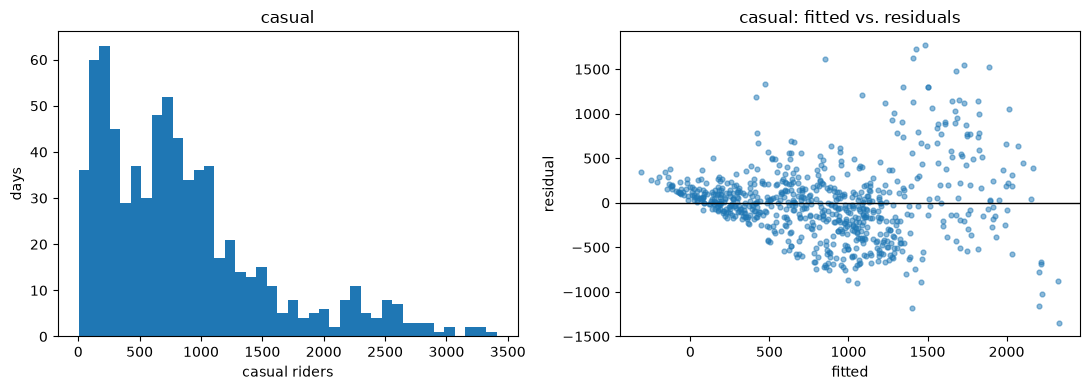

In [22]:
# Q4a Plot a histogram of the count of casual riders. 
# Q4b Fit model and print fitted vs residuals. 

bike_feats = ["temp", "hum", "windspeed", "workingday"]
X_casual = bike[bike_feats]

# This line checks to see if there are any days with zero riders. We will need this for the last part
print("Days with zero casual riders:", (bike["casual"] == 0).sum())

lr_casual = LinearRegression().fit(X_casual, bike["casual"])
fitted_casual = lr_casual.predict(X_casual)
resid_casual = bike["casual"] - fitted_casual

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(bike["casual"], bins=40)
axes[0].set(title="casual", xlabel="casual riders", ylabel="days")
axes[1].scatter(fitted_casual, resid_casual, alpha=0.5, s=12)
axes[1].axhline(0, color="k", lw=1)
axes[1].set(title="casual: fitted vs. residuals", xlabel="fitted", ylabel="residual")
plt.tight_layout()
plt.show()

**Q4a** The shape of this plot is right skewed, most days having fewer than 1500 casual riders, and a long tail going to 3500. 

**Q4b** The fitted vs residuals plot has a clear shape, with the values clustering more at lower numbers and fanning out as fitted values increase. Also note that there are fitted values that fall below zero on the x-axis. This is non-sensical, as we cannot have a negative number of riders on any given day. 

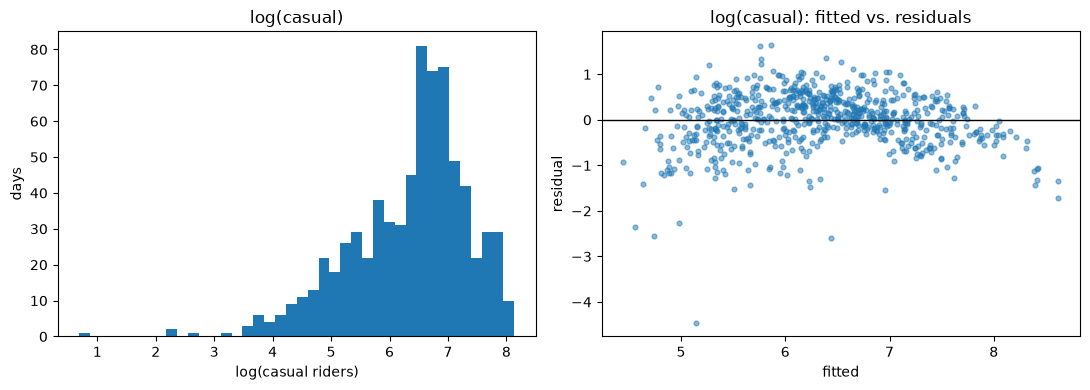

In [23]:
#Q4c 

y_log = np.log(bike["casual"])  # no zeros, so np.log is fine
lr_logcasual = LinearRegression().fit(X_casual, y_log)
fitted_log = lr_logcasual.predict(X_casual)
resid_log = y_log - fitted_log

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y_log, bins=40)
axes[0].set(title="log(casual)", xlabel="log(casual riders)", ylabel="days")
axes[1].scatter(fitted_log, resid_log, alpha=0.5, s=12)
axes[1].axhline(0, color="k", lw=1)
axes[1].set(title="log(casual): fitted vs. residuals", xlabel="fitted", ylabel="residual")
plt.tight_layout()
plt.show()

**Q4c** The histogram is now skewed in the other direction. The residuals plot looks better, and there are no predictions below zero. 

In [24]:
# Comparing coefficients and R^2

coefs_casual = pd.DataFrame({
    "casual": lr_casual.coef_,
    "log(casual)": lr_logcasual.coef_,
}, index=bike_feats)

print("R^2 casual:     ", lr_casual.score(X_casual, bike["casual"]))
print("R^2 log(casual):", lr_logcasual.score(X_casual, y_log))
coefs_casual

R^2 casual:      0.6291179104061355
R^2 log(casual): 0.6601693437078333


,casual,log(casual)
temp,2149.517332,3.847860
hum,-812.741092,-1.462924
windspeed,-1145.309302,-2.029232
workingday,-806.634335,-0.879837


**Q4d** 

Based on our readings last week, it did make sense to try a log transformation, as the original histogram is the exact type of skewed shape where this is recommended. In this instance, it overcorrected a little bit, as the resulting distribution is now skewed in the opposite direction, but there are no more negative predictions. In addition, for the Kepler's law problem, we transformed both the predictors and response variable, and here we transformed the response only. 

Here, the log transformation did *okay* and it was a reasonable approach to try, but it is not as clear of a right choice as we saw for the planets. 
